In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch import nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader

from enflows.flows import Flow
from enflows.distributions.normal import StandardNormal, DiagonalNormal, ConditionalDiagonalNormal
from enflows.transforms import ActNorm, iResBlock, CompositeTransform
from enflows.nn.nets import Sin, ResidualNet

from msi.utils import input_output, plotting, mcmc
from msfm.utils import prior, parameters, files, logger

24-01-18 08:29:38   imports.py INF   Setting up healpy to run on 32 CPUs 


In [3]:
LOGGER = logger.get_logger(os.getcwd())

device = "cuda" if torch.cuda.is_available() else "cpu"

LOGGER.info(f"Available cuda devices: {torch.cuda.device_count()}")
LOGGER.info(f"Running on {device}")

floatx = torch.float32
torch.set_default_dtype(floatx)

24-01-18 08:29:38    notebooks INF   Available cuda devices: 1 
24-01-18 08:29:38    notebooks INF   Running on cuda 


# load network predictions

### v4

In [4]:
# # combined probes
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v4"

# # all parameters
# model_dir = "2023-08-31_03-29-47_resnet_vanilla"

# n_steps = 20000
# params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### v6

In [5]:
# lensing
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing_only"

# delta loss
model_dir = "delta/2024-01-12_19-35-59_resnet_vanilla"

# likelihood loss
# model_dir = "mse/2024-01-05_22-04-15_resnet_vanilla"
# model_dir = "mse/2024-01-08_06-13-14_resnet_vanilla"

n_steps = 100000
params = ["Om", "s8", "w0", "Aia", "n_Aia"]

### general

In [6]:
file_dict = input_output.load_preds(base_dir, model_dir, n_steps)

fidu_preds = file_dict["fiducial/vali/pred"]
grid_preds = file_dict["grid/pred"]
grid_cosmos = file_dict["grid/cosmo"]

# only relevant for the likelihood loss
n_params = len(params)
fidu_preds = fidu_preds[...,:n_params]
grid_preds = grid_preds[...,:n_params]

# combine the example and cosmology axes
grid_preds = np.concatenate(grid_preds, axis=0)
grid_cosmos = np.repeat(grid_cosmos, grid_preds.shape[0]//grid_cosmos.shape[0], axis=0)

print(f"\nShapes after concatenation:")
print(f"grid_preds  = {grid_preds.shape}")
print(f"grid_cosmos = {grid_cosmos.shape}")

24-01-18 08:29:39 input_output INF   Array shapes:
 
24-01-18 08:29:39 input_output INF   fiducial/vali/pred = (4, 5) 
24-01-18 08:29:39 input_output INF   grid/pred          = (2500, 48, 5) 
24-01-18 08:29:39 input_output INF   grid/cosmo         = (2500, 5) 
24-01-18 08:29:39 input_output INF   grid/i_sobol       = (2500,) 
24-01-18 08:29:39 input_output INF   grid/i_example     = (2500, 48) 
24-01-18 08:29:39 input_output INF   grid/i_noise       = (2500, 48) 

Shapes after concatenation:
grid_preds  = (120000, 5)
grid_cosmos = (120000, 5)


In [7]:
out_dir = os.path.join(base_dir, model_dir)
label = f"{n_steps}_conductor"

x_dim = grid_preds.shape[-1]
theta_dim = grid_cosmos.shape[-1]

### observation

In [24]:
# i_obs = 0

i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))
print(f"The example index closest to the median is {i_obs}")

obs_pred = fidu_preds[i_obs]
obs_pred = torch.tensor(obs_pred, dtype=torch.float32, device=device)
obs_pred = obs_pred#.unsqueeze(0)

The example index closest to the median is 1


# posterior Flow $p(\theta|x)$

### architecture

In [9]:
# num_layers = 5
# context_dim = 8
# hidden_dim = 16
# base_dist = ConditionalDiagonalNormal(shape=(x_dim,), context_encoder=nn.Linear(theta_dim, context_dim))

# transforms = []
# for _ in range(num_layers):
#     # transforms.append(ReversePermutation(features=x_dim))
#     transforms.append(MaskedAffineAutoregressiveTransform(
#         features=x_dim, 
#         hidden_features=hidden_dim, 
#         context_features=context_dim
#     )
# )

# transform = CompositeTransform(transforms)

# flow = Flow(transform, base_dist)
# flow = flow.to(device)

### Lipschitz flow

In [10]:
num_layers = 5
num_shared_embedding = 64

# base distribution
# base_dist = DiagonalNormal(shape=(theta_dim,))
base_dist = StandardNormal(shape=(theta_dim,))

# transform
densenet_factory = iResBlock.Factory()
densenet_factory.set_logabsdet_estimator(brute_force=False)
densenet_factory.set_densenet(
    condition_input=True,
    condition_lastlayer=False,
    condition_multiplicative=True,
    # hyperparameters
    dimension=theta_dim,
    densenet_depth=3,
    densenet_growth=32,
    c_embed_hidden_sizes=(128, 128, 10),
    m_embed_hidden_sizes=(128, 128),
    activation_function=Sin(10),
    lip_coeff=.97,
    context_features=num_shared_embedding
)

transforms = []
for i in range(num_layers):
    transforms.append(ActNorm(theta_dim))
    transforms.append(densenet_factory.build())
    
transform = CompositeTransform(transforms)

# context embedding
embedding_net = ResidualNet(
    in_features=x_dim, 
    out_features=num_shared_embedding, 
    hidden_features=32,
    num_blocks=2,
    activation=torch.nn.functional.silu
)

# normalizing flow
flow = Flow(transform, base_dist, embedding_net=embedding_net)
flow = flow.to(device)

### dataset

In [11]:
vali_frac = 0.1

x_all = torch.tensor(grid_preds, dtype=floatx, device=device)
theta_all = torch.tensor(grid_cosmos, dtype=floatx, device=device)

dset = TensorDataset(x_all, theta_all)
train_dset, vali_dset = torch.utils.data.random_split(dset, [1-vali_frac, vali_frac])

### training

In [12]:
n_epochs = 100
n_patience_epochs = 10
batch_size = 2048

clip_by_global_norm = 100
learning_rate = 1e-3
weight_decay = 1e-3

In [13]:
def train_loop(dataloader, flow, optimizer):
    flow.train()
    
    epoch_loss = []
    for batch, (x, theta) in enumerate(dataloader):
        loss = -flow.log_prob(inputs=theta, context=x).mean()
        epoch_loss.append(loss.item())

        # Backpropagation
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), clip_by_global_norm)
        optimizer.step()
        optimizer.zero_grad()
        
    epoch_loss = np.mean(epoch_loss)
    
    return epoch_loss

def vali_loop(dataloader, flow):
    flow.eval()
    
    with torch.no_grad():
        epoch_loss = []
        for x, theta in dataloader:
            loss = -flow.log_prob(inputs=theta, context=x).mean()
            epoch_loss.append(loss.item())

    epoch_loss = np.mean(epoch_loss)
    
    return epoch_loss

In [14]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

train: -2.8110, vali: -3.3314:  95%|█████████▌| 95/100 [06:51<00:21,  4.31s/it]

24-01-18 08:36:32    notebooks INF   Stopping early after 95 epochs 


train: -2.8110, vali: -3.3314:  95%|█████████▌| 95/100 [06:51<00:21,  4.34s/it]


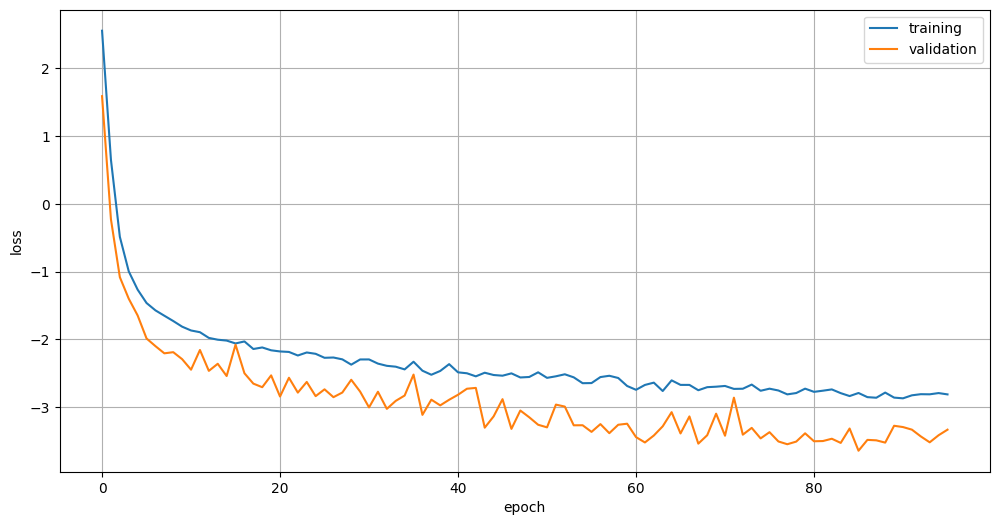

In [15]:
train_loader = DataLoader(train_dset, batch_size, shuffle=True, drop_last=True)
vali_loader = DataLoader(vali_dset, batch_size, shuffle=False, drop_last=True)

optimizer = optim.Adam(flow.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, eta_min=1e-6, T_max=)
early_stopper = EarlyStopper(patience=n_patience_epochs)

pbar = tqdm(range(n_epochs))
train_losses = []
vali_losses = []
for i in pbar:
    train_loss = train_loop(train_loader, flow, optimizer)
    vali_loss = vali_loop(vali_loader, flow)
    
    pbar.set_description(f"train: {train_loss:.4f}, vali: {vali_loss:.4f}")
    train_losses.append(train_loss)
    vali_losses.append(vali_loss)
    
    if early_stopper.early_stop(vali_loss): 
        LOGGER.info(f"Stopping early after {i} epochs")
        break

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(train_losses, label="training")
ax.plot(vali_losses, label="validation")
ax.set(xlabel="epoch", ylabel="loss")
ax.grid(True)
ax.legend()

# direct sampling

In [25]:
n_samples = 10

# samples = flow.sample(num_samples=n_samples, context=obs_pred.repeat(n_samples,1))
samples = flow.sample(num_samples=n_samples, context=obs_pred)#, batch_size=32)

samples = samples.to("cpu").detach().numpy()

ValueError: expected 2D or 3D input (got 1D input)

### plotting

In [26]:
samples.shape

(1, 10, 5)

In [22]:
plotting.plot_chains(
    samples, 
    params, 
    out_dir=out_dir, 
    labels=label,
)

AssertionError: number of names does not match the number of parameters